<a href="https://colab.research.google.com/github/ap-ctrl/celebal_ankita/blob/main/week5_ankita_priyadarshini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



In [3]:
print("\n========== DATASET INFORMATION ==========")
print("Number of characters :", len(corpus))
print("Number of words :", len(corpus.split()))
print("Number of sentences :", len(corpus.strip().split("\n")))


========== DATASET INFORMATION ==========
Number of characters : 291
Number of words : 41
Number of sentences : 6


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [5]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [6]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [7]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

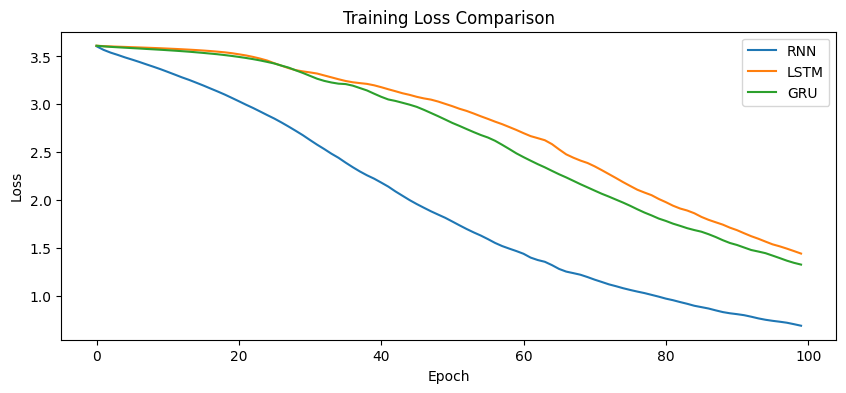

In [8]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [9]:
print("\nFinal Training Loss")
print("---------------------")
print("Vanilla RNN :", round(rnn_history.history['loss'][-1], 4))
print("LSTM        :", round(lstm_history.history['loss'][-1], 4))
print("GRU         :", round(gru_history.history['loss'][-1], 4))


Final Training Loss
---------------------
Vanilla RNN : 0.6883
LSTM        : 1.4416
GRU         : 1.3265


# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [10]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [11]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning is is artificial intelligence than
GRU : deep learning is faster and simpler than


In [12]:
print("\n" + "="*60)
print("Generated Text Quality Comparison")
print("="*60)

rnn_output = generate_text(rnn_model, "deep learning", 5)
lstm_output = generate_text(lstm_model, "deep learning", 5)
gru_output = generate_text(gru_model, "deep learning", 5)

print("Vanilla RNN :", rnn_output)
print("LSTM        :", lstm_output)
print("GRU         :", gru_output)


Generated Text Quality Comparison
Vanilla RNN : deep learning models can generate meaningful sentences
LSTM        : deep learning is is artificial intelligence than
GRU         : deep learning is faster and simpler than


# 🧠 Memory Handling Comparison

Memory handling is one of the major differences between Vanilla RNN, LSTM, and GRU.

- **Vanilla RNN** stores information only in its hidden state. As the sequence becomes longer, earlier information gradually fades due to the vanishing gradient problem.

- **LSTM** introduces a memory cell along with input, forget, and output gates. These gates help preserve important information over long sequences.

- **GRU** simplifies the LSTM architecture by using update and reset gates. It retains long-term information efficiently while requiring fewer parameters and less computation.

### Summary

| Model | Memory Handling |
|--------|-----------------|
| Vanilla RNN | Weak |
| LSTM | Excellent |
| GRU | Very Good |

# 🔗 Long-Term Dependency Learning

Long-term dependency learning refers to a model's ability to remember information that appeared many words earlier in a sequence.

### Vanilla RNN
- Struggles to remember information over long sequences.
- Suffers from the vanishing gradient problem.

### LSTM
- Uses memory cells and gates to preserve important information.
- Performs well on long sequences.

### GRU
- Learns long-term dependencies almost as effectively as LSTM.
- Uses fewer gates, making it computationally more efficient.

### Overall Comparison

| Model | Long-Term Dependency Learning |
|--------|-------------------------------|
| Vanilla RNN | Poor |
| LSTM | Excellent |
| GRU | Very Good |

# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# Load Text Corpus

In [13]:
corpus = '''
A university lecturer struggles to balance academic responsibilities with unexpected romantic feelings.
Her carefully planned career is challenged by changing priorities and emotional uncertainty.
Friendships and workplace relationships influence important personal and professional decisions.
She learns that success involves both intellectual achievement and genuine human connection.
Difficult choices encourage personal growth, honesty, and greater self-understanding over time.
The story explores ambition, love, resilience, and finding happiness beyond academic expectations.
'''

# 🔤 Tokenization & Sequence Creation

In [14]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 64
X shape: (64, 11)
y shape: (64,)


# 🧠 Model 1: Vanilla RNN

In [15]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM

In [17]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU

In [18]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

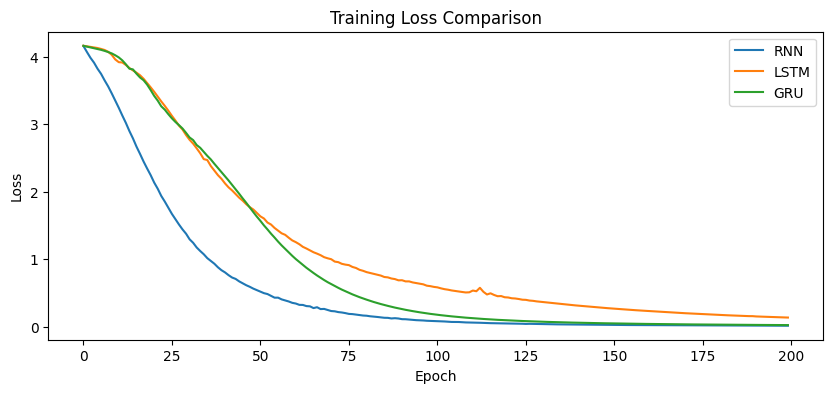

In [19]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [20]:
print("\nFinal Training Loss")
print("---------------------")
print("Vanilla RNN :", round(rnn_history.history['loss'][-1], 4))
print("LSTM        :", round(lstm_history.history['loss'][-1], 4))
print("GRU         :", round(gru_history.history['loss'][-1], 4))


Final Training Loss
---------------------
Vanilla RNN : 0.013
LSTM        : 0.134
GRU         : 0.0224


# ✍️ Text Generation Function

In [21]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [22]:
print("RNN :", generate_text(rnn_model, "university lecturer", 10))
print("LSTM:", generate_text(lstm_model, "university lecturer", 10))
print("GRU :", generate_text(gru_model, "university lecturer", 10))

print("\n" + "="*60)
print("Generated Text Quality Comparison")
print("="*60)

rnn_output = generate_text(rnn_model, "university lecturer", 10)
lstm_output = generate_text(lstm_model, "university lecturer", 10)
gru_output = generate_text(gru_model, "university lecturer", 10)

print("Vanilla RNN :", rnn_output)
print("LSTM        :", lstm_output)
print("GRU         :", gru_output)

RNN : university lecturer struggles to balance academic responsibilities with unexpected romantic feelings is
LSTM: university lecturer lecturer struggles to balance academic responsibilities with unexpected romantic feelings
GRU : university lecturer lecturer struggles to balance academic responsibilities with unexpected romantic feelings

Generated Text Quality Comparison
Vanilla RNN : university lecturer struggles to balance academic responsibilities with unexpected romantic feelings is
LSTM        : university lecturer lecturer struggles to balance academic responsibilities with unexpected romantic feelings
GRU         : university lecturer lecturer struggles to balance academic responsibilities with unexpected romantic feelings


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**